In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")


In [67]:
base_data = pd.read_csv("processed_base_dataset.csv", parse_dates=["Date"])
alt_data  = pd.read_csv("processed_alt_dataset.csv", parse_dates=["Date"])

HORIZON = 10
QUANTILES = [0.1, 0.5, 0.9]

# Use last 10 days for final comparison plots
last_10_base = base_data.tail(10).copy()
last_10_alt  = alt_data.tail(10).copy()

print("Base shape:", base_data.shape)
print("Alt shape:", alt_data.shape)


Base shape: (1761, 30)
Alt shape: (1761, 42)


In [68]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def pinball_loss(y_true, y_pred, q):
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))


def crps_approximation(y_true, q_preds, quantiles):
    total = 0
    for q, pred in zip(quantiles, q_preds):
        total += pinball_loss(y_true, pred, q)
    return total / len(quantiles)


def picp(y_true, lower, upper):
    inside = np.logical_and(y_true >= lower, y_true <= upper)
    return np.mean(inside)


def interval_width(lower, upper):
    return np.mean(upper - lower)


In [69]:
def get_train_test(dataset):
    
    split_index = int(len(dataset) * 0.8)
    
    X = dataset.drop(columns=["Date"] +
                     [f"Target_t+{i}" for i in range(1, HORIZON+1)])
    
    y = dataset["Target_t+10"]  # 10-day ahead forecast
    
    X_train = X.iloc[:split_index]
    X_test  = X.iloc[split_index:]
    
    y_train = y.iloc[:split_index]
    y_test  = y.iloc[split_index:]
    
    return X_train, X_test, y_train, y_test


In [70]:
def train_qrf(X_train, y_train, X_test):
    
    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42
    )
    
    model.fit(X_train.values, y_train.values)
    
    all_tree_preds = np.array([
        tree.predict(X_test.values)
        for tree in model.estimators_
    ])
    
    quantile_preds = []
    
    for q in QUANTILES:
        preds = np.percentile(all_tree_preds, q*100, axis=0)
        quantile_preds.append(preds)
    
    return quantile_preds


In [71]:
def train_xgb_quantile(X_train, y_train, X_test, q):
    
    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    return preds


def train_xgb(X_train, y_train, X_test):
    
    quantile_preds = []
    
    for q in QUANTILES:
        preds = train_xgb_quantile(X_train, y_train, X_test, q)
        quantile_preds.append(preds)
    
    return quantile_preds


In [72]:
def train_prophet(dataset):
    
    df = dataset[["Date", "Gold_Close"]].copy()
    df.columns = ["ds", "y"]
    
    split_index = int(len(df) * 0.8)
    
    train_df = df.iloc[:split_index]
    test_df  = df.iloc[split_index:]
    
    model = Prophet(interval_width=0.8)
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)
    
    preds = forecast.iloc[-len(test_df):]
    
    lower = preds["yhat_lower"].values
    median = preds["yhat"].values
    upper = preds["yhat_upper"].values
    
    return test_df["y"].values, [lower, median, upper]


In [73]:
results = {}

for name, dataset in {"Base": base_data, "Alt": alt_data}.items():
    
    X_train, X_test, y_train, y_test = get_train_test(dataset)
    
    # QRF
    qrf_preds = train_qrf(X_train, y_train, X_test)
    
    # XGB
    xgb_preds = train_xgb(X_train, y_train, X_test)
    
    # Prophet
    y_prophet, prophet_preds = train_prophet(dataset)
    
    results[name] = {
        "y_test": y_test.values,
        "QRF": qrf_preds,
        "XGB": xgb_preds,
        "Prophet": prophet_preds
    }


16:23:13 - cmdstanpy - INFO - Chain [1] start processing
16:23:13 - cmdstanpy - INFO - Chain [1] done processing
16:23:16 - cmdstanpy - INFO - Chain [1] start processing
16:23:16 - cmdstanpy - INFO - Chain [1] done processing


In [74]:
def plot_last_10(actual, preds, model_name, dataset_name):
    
    actual_last10 = actual[-10:]
    lower = preds[0][-10:]
    median = preds[1][-10:]
    upper = preds[2][-10:]
    
    plt.figure()
    plt.plot(actual_last10, label="Actual")
    plt.plot(median, label="Median Forecast")
    plt.fill_between(
        range(10),
        lower,
        upper,
        alpha=0.3
    )
    
    plt.title(f"{model_name} - {dataset_name} (Last 10 Days)")
    plt.legend(loc="lower right")
    plt.show()


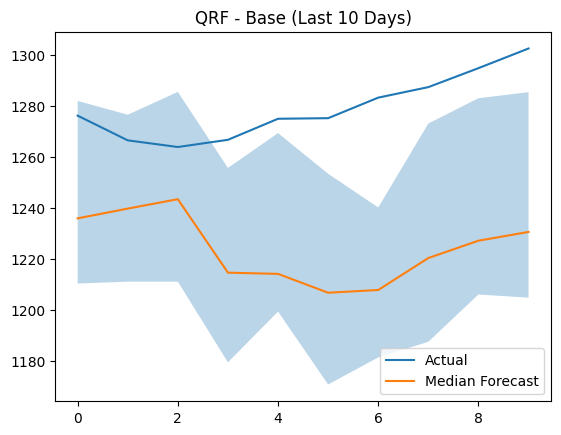

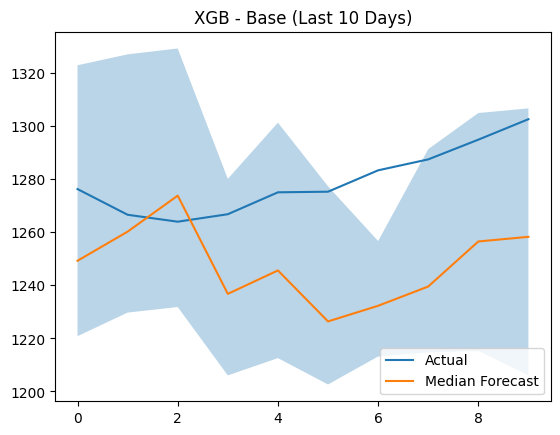

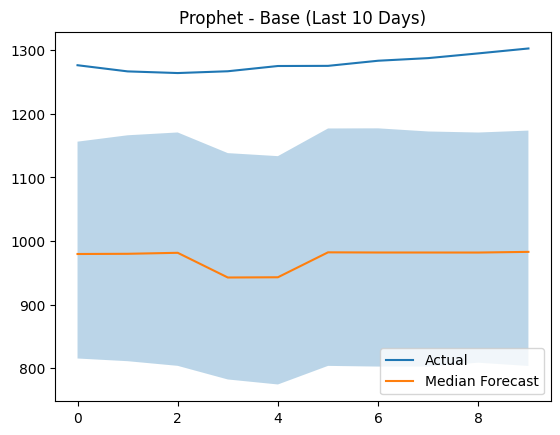

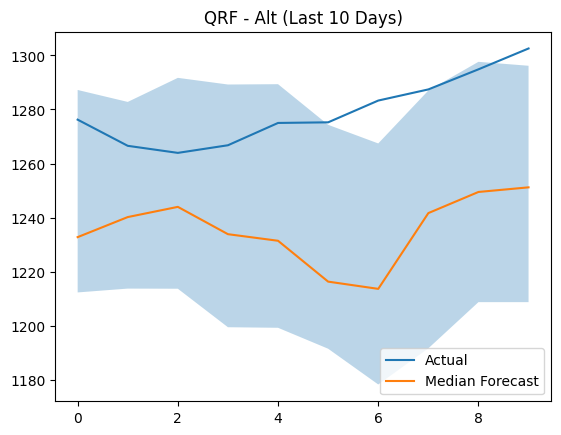

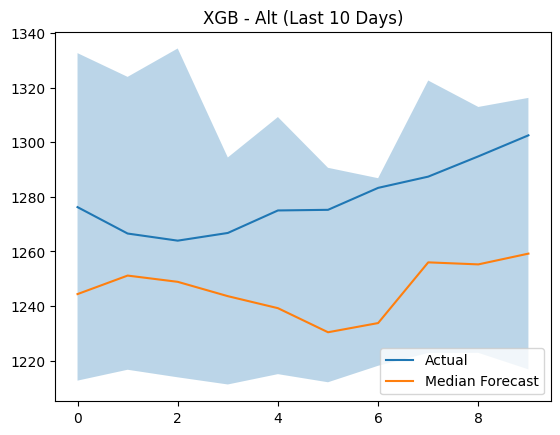

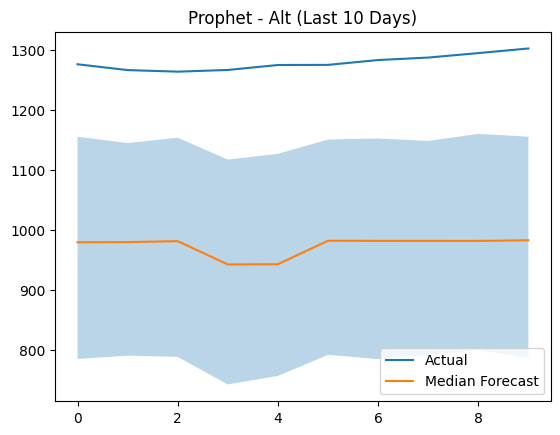

In [75]:
for dataset_name in ["Base", "Alt"]:
    
    y_test = results[dataset_name]["y_test"]
    
    for model in ["QRF", "XGB", "Prophet"]:
        
        preds = results[dataset_name][model]
        plot_last_10(y_test, preds, model, dataset_name)


In [76]:
# ============================================================
# FULL MULTI-HORIZON EVALUATION
# ============================================================

def evaluate_model(dataset, model_type, dataset_name):
    
    results = []
    
    for h in range(1, HORIZON + 1):
        
        target_col = f"Target_t+{h}"
        
        # Feature / target split
        X = dataset.drop(columns=["Date"] + 
                         [f"Target_t+{i}" for i in range(1, HORIZON+1)])
        y = dataset[target_col]
        
        split_index = int(len(dataset) * 0.8)
        
        X_train = X.iloc[:split_index]
        X_test  = X.iloc[split_index:]
        y_train = y.iloc[:split_index]
        y_test  = y.iloc[split_index:]
        
        # ==========================
        # MODEL TRAINING
        # ==========================
        
        if model_type == "QRF":
            preds = train_qrf(X_train, y_train, X_test)
        
        elif model_type == "XGB":
            preds = train_xgb(X_train, y_train, X_test)
        
        elif model_type == "Prophet":
            
            df = dataset[["Date", "Gold_Close"]].copy()
            df.columns = ["ds", "y"]
            
            train_df = df.iloc[:split_index]
            test_df  = df.iloc[split_index:]
            
            model = Prophet(interval_width=0.8)
            model.fit(train_df)
            
            future = model.make_future_dataframe(periods=len(test_df), freq='D')
            forecast = model.predict(future)
            preds_df = forecast.iloc[-len(test_df):]
            
            preds = [
                preds_df["yhat_lower"].values,
                preds_df["yhat"].values,
                preds_df["yhat_upper"].values
            ]
            
            y_test = test_df["y"].values
        
        # ==========================
        # METRICS
        # ==========================
        
        lower = preds[0]
        median = preds[1]
        upper = preds[2]
        
        crps_val = crps_approximation(y_test, preds, QUANTILES)
        picp_val = picp(y_test, lower, upper)
        width_val = interval_width(lower, upper)
        rmse_val = rmse(y_test, median)
        
        results.append({
            "Dataset": dataset_name,
            "Model": model_type,
            "Horizon": h,
            "CRPS": crps_val,
            "PICP": picp_val,
            "Interval_Width": width_val,
            "RMSE": rmse_val
        })
    
    df_results = pd.DataFrame(results)
    
    # Add summary row (average across horizons)
    summary_avg = df_results.mean(numeric_only=True)
    summary_avg["Dataset"] = dataset_name
    summary_avg["Model"] = model_type
    summary_avg["Horizon"] = "Average"
    
    df_results = pd.concat([df_results, pd.DataFrame([summary_avg])], ignore_index=True)
    
    return df_results


all_results = []

for dataset_name, dataset in {"Base": base_data, "Alt": alt_data}.items():
    
    for model in ["QRF", "XGB", "Prophet"]:
        
        print(f"Evaluating {model} - {dataset_name}")
        
        model_results = evaluate_model(dataset, model, dataset_name)
        all_results.append(model_results)

final_results = pd.concat(all_results, ignore_index=True)

display(final_results)


Evaluating QRF - Base
Evaluating XGB - Base
Evaluating Prophet - Base


11:02:30 - cmdstanpy - INFO - Chain [1] start processing
11:02:31 - cmdstanpy - INFO - Chain [1] done processing
11:02:31 - cmdstanpy - INFO - Chain [1] start processing
11:02:32 - cmdstanpy - INFO - Chain [1] done processing
11:02:33 - cmdstanpy - INFO - Chain [1] start processing
11:02:34 - cmdstanpy - INFO - Chain [1] done processing
11:02:35 - cmdstanpy - INFO - Chain [1] start processing
11:02:36 - cmdstanpy - INFO - Chain [1] done processing
11:02:38 - cmdstanpy - INFO - Chain [1] start processing
11:02:39 - cmdstanpy - INFO - Chain [1] done processing
11:02:40 - cmdstanpy - INFO - Chain [1] start processing
11:02:40 - cmdstanpy - INFO - Chain [1] done processing
11:02:42 - cmdstanpy - INFO - Chain [1] start processing
11:02:43 - cmdstanpy - INFO - Chain [1] done processing
11:02:44 - cmdstanpy - INFO - Chain [1] start processing
11:02:45 - cmdstanpy - INFO - Chain [1] done processing
11:02:46 - cmdstanpy - INFO - Chain [1] start processing
11:02:46 - cmdstanpy - INFO - Chain [1]

Evaluating QRF - Alt
Evaluating XGB - Alt
Evaluating Prophet - Alt


11:04:43 - cmdstanpy - INFO - Chain [1] start processing
11:04:43 - cmdstanpy - INFO - Chain [1] done processing
11:04:45 - cmdstanpy - INFO - Chain [1] start processing
11:04:45 - cmdstanpy - INFO - Chain [1] done processing
11:04:46 - cmdstanpy - INFO - Chain [1] start processing
11:04:47 - cmdstanpy - INFO - Chain [1] done processing
11:04:48 - cmdstanpy - INFO - Chain [1] start processing
11:04:48 - cmdstanpy - INFO - Chain [1] done processing
11:04:49 - cmdstanpy - INFO - Chain [1] start processing
11:04:50 - cmdstanpy - INFO - Chain [1] done processing
11:04:51 - cmdstanpy - INFO - Chain [1] start processing
11:04:51 - cmdstanpy - INFO - Chain [1] done processing
11:04:52 - cmdstanpy - INFO - Chain [1] start processing
11:04:53 - cmdstanpy - INFO - Chain [1] done processing
11:04:54 - cmdstanpy - INFO - Chain [1] start processing
11:04:54 - cmdstanpy - INFO - Chain [1] done processing
11:04:55 - cmdstanpy - INFO - Chain [1] start processing
11:04:56 - cmdstanpy - INFO - Chain [1]

,Dataset,Model,Horizon,CRPS,PICP,Interval_Width,RMSE
0,Base,QRF,1,2.959022,0.767705,26.258569,11.893238
1,Base,QRF,2,4.604141,0.739377,39.828304,18.577658
2,Base,QRF,3,5.678306,0.688385,47.378051,21.873345
3,Base,QRF,4,6.647257,0.705382,55.111560,25.871401
4,Base,QRF,5,7.613785,0.711048,62.674106,29.570219
...,...,...,...,...,...,...,...
61,Alt,Prophet,7,93.539121,0.025496,196.599024,244.675406
62,Alt,Prophet,8,92.858535,0.025496,192.194092,244.675406
63,Alt,Prophet,9,91.812766,0.025496,188.869697,244.675406
64,Alt,Prophet,10,92.639525,0.028329,193.140285,244.675406


In [77]:
# Split final results table and display results side by side

from IPython.display import display, HTML

def display_side_by_side(df1, df2, title1="", title2=""):
    
    html = f"""
    <div style="display:flex; gap:40px;">
        <div>
            <h3>{title1}</h3>
            {df1.to_html(index=False)}
        </div>
        <div>
            <h3>{title2}</h3>
            {df2.to_html(index=False)}
        </div>
    </div>
    """
    
    display(HTML(html))


models = ["QRF", "XGB", "Prophet"]

for model in models:
    
    base_table = final_results[
        (final_results["Dataset"] == "Base") &
        (final_results["Model"] == model)
    ][["Horizon", "CRPS", "PICP", "Interval_Width", "RMSE"]]
    
    alt_table = final_results[
        (final_results["Dataset"] == "Alt") &
        (final_results["Model"] == model)
    ][["Horizon", "CRPS", "PICP", "Interval_Width", "RMSE"]]
    
    display_side_by_side(
        base_table,
        alt_table,
        title1=f"{model} - Base Dataset",
        title2=f"{model} - Alternative Dataset"
    )


Horizon,CRPS,PICP,Interval_Width,RMSE
1,2.959022,0.767705,26.258569,11.893238
2,4.604141,0.739377,39.828304,18.577658
3,5.678306,0.688385,47.378051,21.873345
4,6.647257,0.705382,55.111560,25.871401
5,7.613785,0.711048,62.674106,29.570219
6,8.899928,0.677054,72.626090,34.883935
7,10.146901,0.628895,76.664844,38.367284
8,11.396838,0.628895,80.105504,42.327162
9,12.856602,0.589235,85.687804,46.836821
10,13.871501,0.583569,88.240945,50.003514


Horizon,CRPS,PICP,Interval_Width,RMSE
1,4.723097,0.869688,48.813702,21.559425
2,5.798786,0.662890,36.120716,28.255293
3,7.058120,0.750708,49.955948,32.498093
4,7.900584,0.722380,55.693497,38.174856
5,7.578887,0.728045,63.445175,31.089710
6,8.453342,0.679887,64.608582,36.050862
7,9.241134,0.696884,76.767349,39.803008
8,9.804961,0.677054,83.088600,40.171865
9,10.698711,0.708215,93.155434,45.217135
10,11.636238,0.668555,88.194298,47.320442


Horizon,CRPS,PICP,Interval_Width,RMSE
1,92.957588,0.025496,190.273348,244.675406
2,91.941440,0.022663,195.662822,244.675406
3,93.483379,0.025496,191.655282,244.675406
4,93.587759,0.025496,185.947061,244.675406
5,93.926032,0.022663,194.313988,244.675406
6,93.361562,0.025496,192.128131,244.675406
7,92.992486,0.028329,189.222704,244.675406
8,92.584962,0.025496,200.867577,244.675406
9,92.106217,0.022663,188.947509,244.675406
10,92.001699,0.022663,191.699294,244.675406


In [78]:
average_comparison = final_results[final_results["Horizon"] == "Average"]

average_comparison = average_comparison[[
    "Dataset",
    "Model",
    "CRPS",
    "PICP",
    "Interval_Width",
    "RMSE"
]]

display(average_comparison)


,Dataset,Model,CRPS,PICP,Interval_Width,RMSE
10,Base,QRF,8.467428,0.671955,63.457578,32.020458
21,Base,XGB,8.289386,0.716431,65.984329,36.014069
32,Base,Prophet,92.894312,0.024646,192.071772,244.675406
43,Alt,QRF,8.695215,0.669688,65.102116,33.534639
54,Alt,XGB,8.436663,0.756657,70.364769,37.310368
65,Alt,Prophet,92.351029,0.025212,192.594995,244.675406


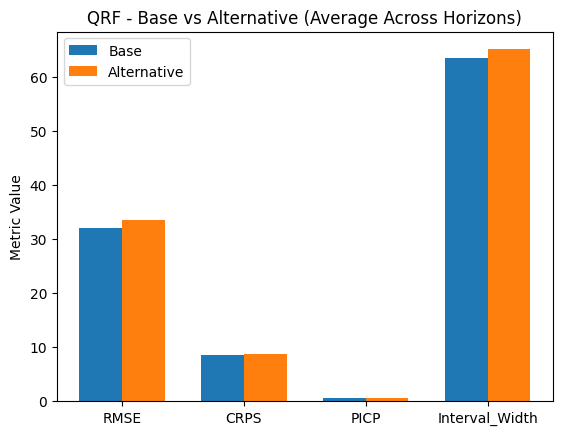

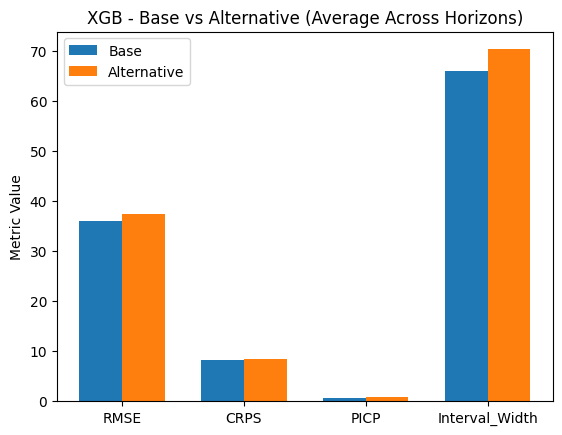

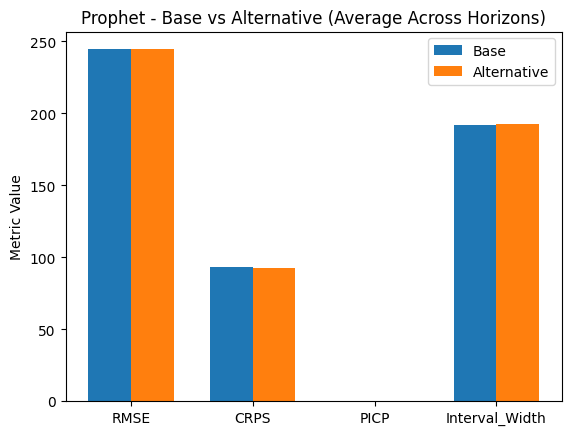

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Filter only average rows
avg_results = final_results[final_results["Horizon"] == "Average"].copy()

metrics = ["RMSE", "CRPS", "PICP", "Interval_Width"]
models = ["QRF", "XGB", "Prophet"]

for model in models:
    
    model_data = avg_results[avg_results["Model"] == model]
    
    base_vals = model_data[model_data["Dataset"] == "Base"][metrics].values.flatten()
    alt_vals  = model_data[model_data["Dataset"] == "Alt"][metrics].values.flatten()
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.figure()
    
    plt.bar(x - width/2, base_vals, width, label="Base")
    plt.bar(x + width/2, alt_vals, width, label="Alternative")
    
    plt.xticks(x, metrics)
    plt.title(f"{model} - Base vs Alternative (Average Across Horizons)")
    plt.legend()
    
    plt.ylabel("Metric Value")
    plt.show()
